In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# Module 5 Lab 1: Chart It, Then Test It
# module5_lab.ipynb
# Instructor Seno
# 9/29/2026

## Step 1: Group means for chick feeds

#### Load chickwts.csv and Download chickwts.csv and compute mean weight per feed type, sorted (Tutorial 4 pattern).  You should see: six feeds; casein highest, horsebean lowest.

In [2]:
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("chickwts.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'weight', 'feed'], dtype='str')

In [4]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

## Step 2: Sorted bar chart
#### Bar-chart mean weight by feed (Tutorial 1: seaborn ), fully labeled (Tutorial 2: titles and labels) with a title that states the takeaway and a y-axis in grams.  You should see: sorted bars with casein tallest, readable labels.

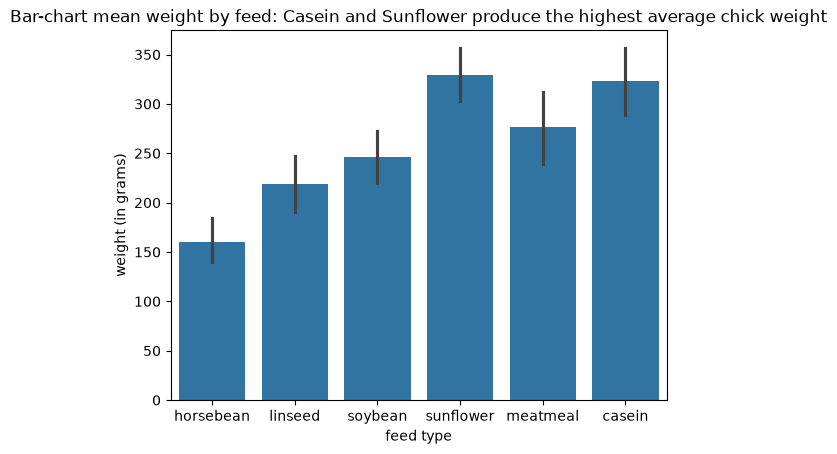

In [5]:
sns.barplot(data=df, x="feed", y="weight")
plt.title("Bar-chart mean weight by feed: Casein and Sunflower produce the highest average chick weight")
plt.xlabel("feed type")
plt.ylabel("weight (in grams)")
plt.show()

## Step 3: Histogram of all weights
#### Histogram of weight with about 15 bins, labeled.  You should see: a roughly symmetric distribution centered near 260 g.

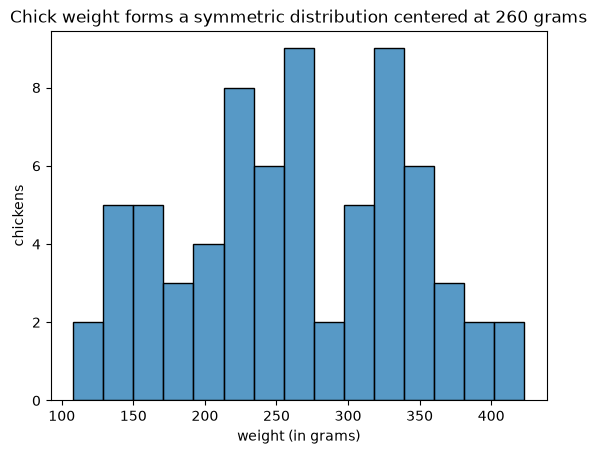

In [6]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Chick weight forms a symmetric distribution centered at 260 grams")
plt.xlabel("weight (in grams)")
plt.ylabel("chickens")
plt.show()

## Step 4: Line chart of museum visitors
#### Load museum_visitors.csand line-chart visitors over time (Tutorial 3), labeled. In one markdown line, note one visible trend.  You should see: a labeled line chart and one observed pattern.

In [7]:
df_2 = pd.read_csv("museum_visitors.csv")

In [8]:
df_2.columns

Index(['Date', 'Avila Adobe', 'Firehouse Museum', 'Chinese American Museum',
       'America Tropical Interpretive Center'],
      dtype='str')

In [9]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Date                                  59 non-null     str  
 1   Avila Adobe                           59 non-null     int64
 2   Firehouse Museum                      59 non-null     int64
 3   Chinese American Museum               59 non-null     int64
 4   America Tropical Interpretive Center  59 non-null     int64
dtypes: int64(4), str(1)
memory usage: 2.4 KB


In [10]:
df_2.head()

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


In [11]:
df_2["Date"] = pd.to_datetime(df_2["Date"]) #, format="mixed")

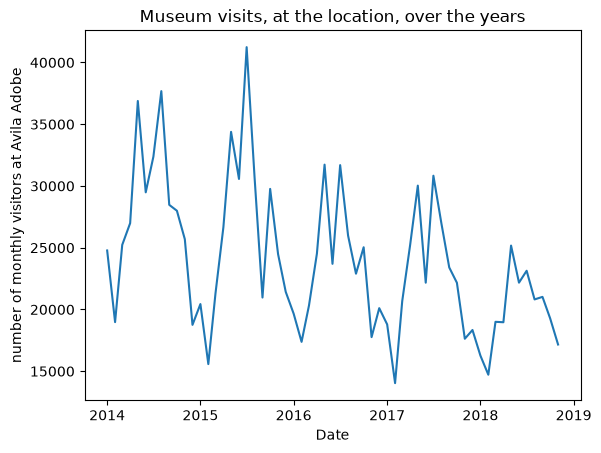

In [12]:
sns.lineplot(data=df_2, x="Date", y="Avila Adobe")
plt.title("Museum visits, at the location, over the years")
plt.xlabel("Date")
plt.ylabel("number of monthly visitors at Avila Adobe")
plt.show()

#### The visits to Availa Adobe look like they occur twice annually, as time elapses the visits at twice a year, dwindle from 35000, to 25000. 

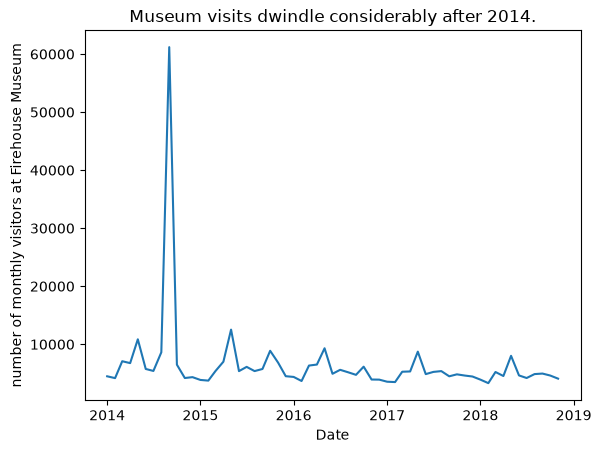

In [13]:
sns.lineplot(data=df_2, x="Date", y="Firehouse Museum")
plt.title("Museum visits dwindle considerably after 2014.")
plt.xlabel("Date")
plt.ylabel("number of monthly visitors at Firehouse Museum")
plt.show()

#### The visitors display a spike in 2014 reaching an all time high at 60,000, but from 2015 to 2019 visitations stalemate at 10,000 people. 

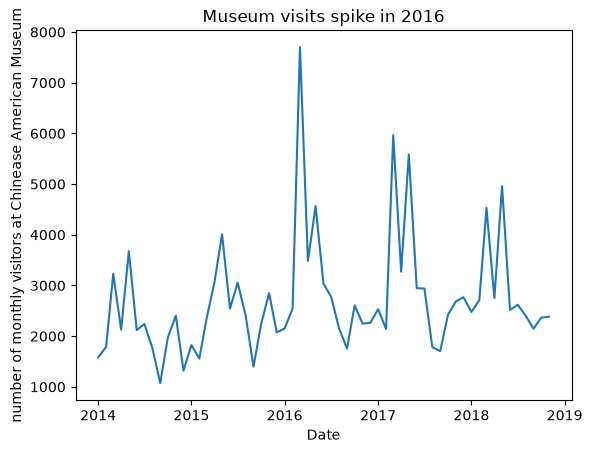

In [14]:
sns.lineplot(data=df_2, x="Date", y="Chinese American Museum")
plt.title("Museum visits spike in 2016")
plt.xlabel("Date")
plt.ylabel("number of monthly visitors at Chinease American Museum")
plt.show()

#### Chinease American interests spiked in 2016. Steady visits occur twice per month.

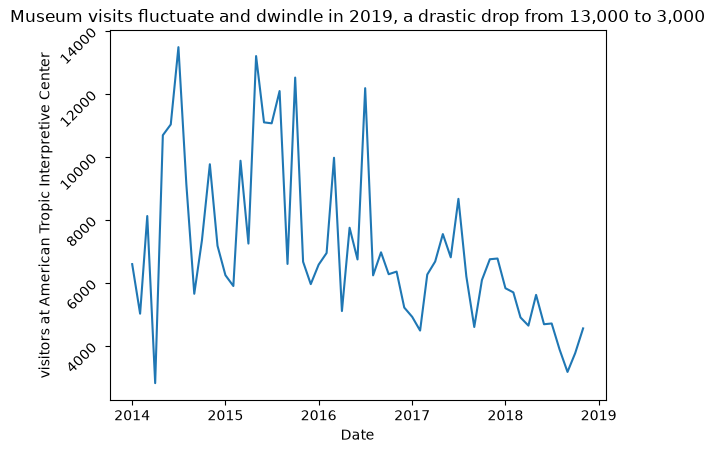

In [15]:
sns.lineplot(data=df_2, x="Date", y="America Tropical Interpretive Center")
plt.title("Museum visits fluctuate and dwindle in 2019, a drastic drop from 13,000 to 3,000")
plt.xlabel("Date")
plt.ylabel("visitors at American Tropic Interpretive Center")
plt.yticks(rotation=45)
plt.show()

#### Unpredictability and a drastic drop of visits in 2019.  The ATIC has seen it's final spike of interest.

## Step 5: Scatter and heatmap on your sales data
#### With your Module 4 sales data: scatter qty vs. revenue, and make a correlation heatmap with sns.heatmap(df.corr(numeric_only=True), annot=True). State the strongest off-diagonal correlation in markdown.  You should see: the heatmap’s annotated numbers match what you found in Lab 4.

<Axes: >

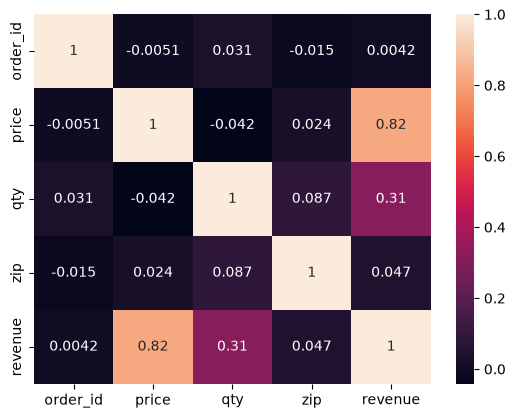

In [16]:
df_3 = pd.read_csv("sales_clean_revenue.csv")
sns.heatmap(df_3.corr(numeric_only=True), annot=True)

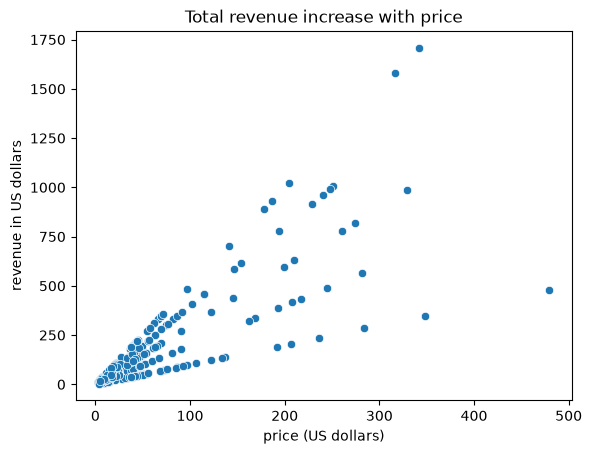

In [17]:
sns.scatterplot(data=df_3, x="price", y="revenue")
plt.title("Total revenue increase with price")
plt.xlabel("price (US dollars)")
plt.ylabel("revenue in US dollars")
plt.show()

#### In module 4 the making of a correlation requires that a heatmap square to be between **-1 to -0.5 or +0.5 to +1**  That means .82 indicates a strong correlation between **price and revenue.**

## Step 6: State the hypothesis (markdown cell)
#### You will compare casein-fed and horsebean-fed chicks. Write the null hypothesis in one sentence.

#### Null hyothesis says there is no effect, no difference between the groups, a random variation, or skeptical postion.  This means the feed would be no difference between **horsebean** or **casein**  The observations made about casein being better and more fattening than horsebean, because the chickens weiged more in grams, is due to random chance.

## Step 7: Run the t-test
#### Extract the two feed groups’ weights and run ttest_ind (Tutorial 5 pattern adapted to the chick data).  You should see: a large t (about 7 or more) and a p-value far below 0.05.

In [18]:
# grouped means befor the chart
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

In [19]:
from scipy.stats import ttest_ind
a = df[df["feed"] == "casein"]["weight"]
b = df[df["feed"] == "horsebean"]["weight"]
ttest_ind(a, b)

TtestResult(statistic=np.float64(7.019741040397541), pvalue=np.float64(8.254541016953185e-07), df=np.float64(20.0))

#### the scope or order of a, b makes the t positive or negative.
#### p-value: a very small number: 8.254541016953185e-07 
#### large t: 7.019741040397541

## Step 8: The conclusion sentence (markdown cell)
#### One sentence containing: the difference in grams (effect size), the p-value, your verdict, and one caution (sample size, or that this is one farm’s data).

#### In the groupby() function, we were able to see the differences between the averages of chick weight of two types of feed. Horsebean is at 160.20 and casein is at 323.58.  A difference of **163.38 grams** between the two types of feed.  We look at the p value which is less than 0.001 and we ill reject the null hypothesis.  This was a small dataset, from a single farm.  It is possible that an enormous dataset from different farms, would yield differnt results, however in this type of environment the dataset points to a conclusion that casein builds heavier chickens al least heavier than horsebeanwhich could be due to fat content or better flavor and painless digestion.

## Step 9: Honest-chart audit (markdown cell)
#### Pick one of your charts and name two design choices you made for honesty (zero baseline, units, palette, no truncation).

#### For honesty I tried to prevent labels from overlapping into a smear with plt.xticks(rotation=45)  plt.yticks(rotation=45) allowing more descriptive writing on the chart.

#### From lecture 5.1 how bars mislead, The axis starts at 0. Zero baseline starts at zero to ensure the height of the bars ae true of the weights to prevent truncated axis.  sns.barplot() function from seaborn.  When Seaborn draws the bars, it calculates the y-axis at 0 so the bars are accurate.

#### The units on the y-axis are clearly labeled in grams, this clarifies the chick weight is not in pounds.  These two genuine design choices will prove to be essential in future charts development.

## Behzad Ghabaei - End Of Lab